# 🦠 COVID-19 City-Level Interactive Dashboard
### Built with Plotly · Seaborn · ipywidgets · Pandas · Matplotlib
---
> **Instructions:** Run all cells top-to-bottom. Use the widgets at each section to interact with the visualizations.

## 📦 1. Install & Import Dependencies

In [3]:
# ── Install required libraries (only needed once) ──────────────────────────
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for lib in ['plotly', 'ipywidgets', 'seaborn', 'nbformat', 'kaleido']:
    install(lib)

print('✅ All packages ready.')

✅ All packages ready.


In [4]:
# ── Core imports ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ── Global style tweaks ─────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.facecolor': '#0f172a', 'axes.facecolor': '#1e293b',
                     'text.color': 'white', 'axes.labelcolor': 'white',
                     'xtick.color': 'white', 'ytick.color': 'white',
                     'grid.color': '#334155', 'font.size': 11})

PLOTLY_TEMPLATE = 'plotly_dark'
ACCENT_COLORS   = px.colors.qualitative.Vivid

print('✅ Imports successful.')

✅ Imports successful.


---
## 🗄️ 2. Synthetic Dataset Generation
*Replace `generate_dataset()` with `pd.read_csv('your_file.csv')` to use real data.*

In [5]:
# ── Generate realistic city-level COVID-19 time-series data ─────────────────
def generate_dataset(seed: int = 42) -> pd.DataFrame:
    """
    Creates a synthetic COVID-19 dataset mimicking real wave patterns.
    Columns: city | date | confirmed | active | recovered | deaths
    """
    np.random.seed(seed)
    rng = pd.date_range('2020-03-01', '2023-12-31', freq='D')

    # City parameters: (population_scale, wave_intensity, recovery_rate, fatality_rate)
    cities = {
        'Mumbai':    (1.8, 1.2, 0.94, 0.018),
        'Delhi':     (2.0, 1.5, 0.93, 0.022),
        'Bangalore': (1.3, 0.9, 0.95, 0.015),
        'Chennai':   (1.1, 1.0, 0.94, 0.017),
        'Kolkata':   (1.0, 0.8, 0.92, 0.020),
        'Hyderabad': (0.9, 0.7, 0.95, 0.014),
        'Pune':      (0.8, 1.1, 0.93, 0.016),
        'Ahmedabad': (0.7, 0.9, 0.91, 0.021),
    }

    # Wave peaks — simulating Alpha, Delta, Omicron surges
    wave_peaks = [
        (pd.Timestamp('2020-09-15'), 0.30),
        (pd.Timestamp('2021-05-10'), 0.70),
        (pd.Timestamp('2022-01-20'), 0.90),
        (pd.Timestamp('2022-07-01'), 0.20),
    ]

    def wave_signal(dates):
        """Superposition of Gaussian waves to simulate infection waves."""
        sig = np.zeros(len(dates))
        days = (dates - dates[0]).days
        for peak_date, height in wave_peaks:
            center = (peak_date - dates[0]).days
            sig += height * np.exp(-((days - center) ** 2) / (2 * 60**2))
        return np.clip(sig, 0, 1)

    base_signal = wave_signal(rng)
    records = []

    for city, (scale, intensity, rec_rate, fat_rate) in cities.items():
        noise       = np.random.normal(0, 0.03, len(rng))
        city_signal = np.clip(base_signal * intensity * scale + noise, 0, None)

        # Daily new cases from the signal
        daily_new = (city_signal * 12_000 * np.random.uniform(0.85, 1.15, len(rng))).astype(int)
        daily_new = np.maximum(daily_new, 0)

        confirmed_cumsum = daily_new.cumsum()
        deaths           = (confirmed_cumsum * fat_rate * np.random.uniform(0.97, 1.03, len(rng))).astype(int)
        recovered        = (confirmed_cumsum * rec_rate * np.random.uniform(0.97, 1.03, len(rng))).astype(int)
        recovered        = np.minimum(recovered, confirmed_cumsum - deaths)  # sanity check
        active           = confirmed_cumsum - recovered - deaths
        active           = np.maximum(active, 0)

        for i, date in enumerate(rng):
            records.append({
                'city':      city,
                'date':      date,
                'confirmed': int(confirmed_cumsum[i]),
                'active':    int(active[i]),
                'recovered': int(recovered[i]),
                'deaths':    int(deaths[i]),
            })

    df = pd.DataFrame(records)

    # ── Introduce realistic missing values (≈1.5%) ──────────────────────────
    for col in ['active', 'recovered', 'deaths']:
        mask = np.random.rand(len(df)) < 0.015
        df.loc[mask, col] = np.nan

    return df


# ── Load & clean ─────────────────────────────────────────────────────────────
def load_and_clean(df: pd.DataFrame) -> pd.DataFrame:
    """Parse dates, forward-fill missing values, derive helper columns."""
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values(['city', 'date'], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Forward-fill per city (handles NaN spikes in cumulative cols)
    fill_cols = ['confirmed', 'active', 'recovered', 'deaths']
    df[fill_cols] = df.groupby('city')[fill_cols].transform(lambda g: g.ffill().bfill())

    # Derived columns
    df['daily_new']    = df.groupby('city')['confirmed'].diff().clip(lower=0)
    df['growth_rate']  = df.groupby('city')['confirmed'].pct_change() * 100
    df['growth_rate']  = df['growth_rate'].clip(-100, 200).round(2)
    df['fatality_pct'] = (df['deaths'] / df['confirmed'].replace(0, np.nan) * 100).round(3)
    df['recovery_pct'] = (df['recovered'] / df['confirmed'].replace(0, np.nan) * 100).round(3)
    df['month_year']   = df['date'].dt.to_period('M').astype(str)
    df['week']         = df['date'].dt.isocalendar().week.astype(int)
    df['year']         = df['date'].dt.year

    return df


RAW = generate_dataset()
DF  = load_and_clean(RAW)

CITIES     = sorted(DF['city'].unique().tolist())
DATE_MIN   = DF['date'].min()
DATE_MAX   = DF['date'].max()

print(f'✅ Dataset ready — {len(DF):,} rows | {len(CITIES)} cities | '
      f'{DATE_MIN.date()} → {DATE_MAX.date()}')
DF.head()

✅ Dataset ready — 11,208 rows | 8 cities | 2020-03-01 → 2023-12-31


,city,date,confirmed,active,recovered,deaths,daily_new,growth_rate,fatality_pct,recovery_pct,month_year,week,year
0,Ahmedabad,2020-03-01,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,2020-03,9,2020
1,Ahmedabad,2020-03-02,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,2020-03,10,2020
2,Ahmedabad,2020-03-03,80,5.0,74.0,1.0,80.0,200.0,1.250,92.500,2020-03,10,2020
3,Ahmedabad,2020-03-04,289,14.0,270.0,5.0,209.0,200.0,1.730,93.426,2020-03,10,2020
4,Ahmedabad,2020-03-05,289,20.0,263.0,6.0,0.0,0.0,2.076,91.003,2020-03,10,2020


---
## 🖥️ 3. Dashboard Styling Helpers

In [6]:
# ── Inject CSS for KPI cards and overall dashboard look ─────────────────────
DASHBOARD_CSS = """
<style>
  /* Notebook body background */
  body, .jp-Notebook { background: #0f172a !important; }

  /* Section headers */
  .dash-section {
    background: linear-gradient(90deg,#1e3a5f,#0f172a);
    color:#e2e8f0; padding:10px 18px; border-radius:8px;
    margin:10px 0 6px; font-size:16px; font-weight:700;
    border-left:4px solid #3b82f6; letter-spacing:.5px;
  }

  /* KPI card grid */
  .kpi-grid {
    display:grid; grid-template-columns:repeat(4,1fr);
    gap:14px; margin:14px 0;
  }
  .kpi-card {
    background:linear-gradient(135deg,#1e293b,#0f172a);
    border-radius:12px; padding:18px 20px;
    border:1px solid #334155; box-shadow:0 4px 20px rgba(0,0,0,.4);
    transition:transform .2s;
  }
  .kpi-card:hover { transform:translateY(-3px); }
  .kpi-label  { color:#94a3b8; font-size:12px; text-transform:uppercase;
                letter-spacing:1px; margin-bottom:6px; }
  .kpi-value  { font-size:26px; font-weight:800; }
  .kpi-delta  { font-size:12px; margin-top:4px; }
  .kpi-blue   .kpi-value { color:#60a5fa; }
  .kpi-yellow .kpi-value { color:#fbbf24; }
  .kpi-red    .kpi-value { color:#f87171; }
  .kpi-green  .kpi-value { color:#34d399; }

  /* Widget label text */
  .widget-label { color:#94a3b8 !important; font-size:13px !important; }
  .widget-box   { background:#1e293b !important; border-radius:8px;
                  padding:10px; border:1px solid #334155; }
</style>
"""
display(HTML(DASHBOARD_CSS))
print('✅ CSS injected.')

✅ CSS injected.


---
## 🔧 4. Reusable Helper Functions

In [7]:
# ── Data Utilities ───────────────────────────────────────────────────────────

def filter_data(df: pd.DataFrame, city: str,
                start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    """Return rows for a single city within the date range."""
    mask = (df['city'] == city) & (df['date'] >= start) & (df['date'] <= end)
    return df.loc[mask].copy()


def filter_multi(df: pd.DataFrame, cities: list,
                 start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    """Return rows for multiple cities within the date range."""
    mask = df['city'].isin(cities) & (df['date'] >= start) & (df['date'] <= end)
    return df.loc[mask].copy()


def fmt(n: float) -> str:
    """Format large numbers (e.g. 1200000 → 1.20M)."""
    if pd.isna(n): return 'N/A'
    n = int(n)
    if n >= 1_000_000: return f'{n/1_000_000:.2f}M'
    if n >= 1_000:     return f'{n/1_000:.1f}K'
    return str(n)


def latest_kpis(sub: pd.DataFrame) -> dict:
    """Extract the latest cumulative KPIs from a city slice."""
    last = sub.iloc[-1]
    prev = sub.iloc[-2] if len(sub) > 1 else last
    return {
        'confirmed': last['confirmed'],
        'active':    last['active'],
        'deaths':    last['deaths'],
        'recovered': last['recovered'],
        'daily_new': last['daily_new'],
        'growth':    last['growth_rate'],
        'cfr':       last['fatality_pct'],
        'delta_conf': last['confirmed'] - prev['confirmed'],
    }


# ── KPI Card Renderer ────────────────────────────────────────────────────────

def render_kpi_cards(kpis: dict) -> None:
    """Display 4 KPI cards as HTML."""
    cards = [
        ('kpi-blue',   '🔵 Total Confirmed',  fmt(kpis['confirmed']),
         f"+{fmt(kpis['delta_conf'])} from prev day"),
        ('kpi-yellow', '🟡 Active Cases',      fmt(kpis['active']),
         f"Growth rate: {kpis['growth']:.2f}%"),
        ('kpi-red',    '🔴 Deaths',            fmt(kpis['deaths']),
         f"CFR: {kpis['cfr']:.3f}%"),
        ('kpi-green',  '🟢 Recovered',         fmt(kpis['recovered']),
         f"Daily new: {fmt(kpis['daily_new'])}"),
    ]
    html = '<div class="kpi-grid">'
    for cls, label, value, delta in cards:
        html += f"""
        <div class="kpi-card {cls}">
          <div class="kpi-label">{label}</div>
          <div class="kpi-value">{value}</div>
          <div class="kpi-delta" style="color:#64748b">{delta}</div>
        </div>"""
    html += '</div>'
    display(HTML(html))


print('✅ Helpers defined.')

✅ Helpers defined.


---
## 📊 5. Plot Functions

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT A — Multi-metric Line Chart (Plotly)
# ══════════════════════════════════════════════════════════════════════════════
def plot_line_chart(sub: pd.DataFrame, city: str) -> go.Figure:
    """Interactive line chart: confirmed / active / recovered / deaths over time."""
    fig = go.Figure()
    metrics = [
        ('confirmed', '#60a5fa', 'Total Confirmed'),
        ('active',    '#fbbf24', 'Active Cases'),
        ('recovered', '#34d399', 'Recovered'),
        ('deaths',    '#f87171', 'Deaths'),
    ]
    for col, color, label in metrics:
        fig.add_trace(go.Scatter(
            x=sub['date'], y=sub[col],
            name=label, line=dict(color=color, width=2),
            hovertemplate=f'<b>{label}</b>: %{{y:,.0f}}<br>Date: %{{x|%d %b %Y}}<extra></extra>'
        ))
    fig.update_layout(
        title=dict(text=f'📈 COVID-19 Trends — {city}', font=dict(size=18)),
        template=PLOTLY_TEMPLATE,
        xaxis=dict(title='Date', rangeslider=dict(visible=True), type='date'),
        yaxis=dict(title='Cumulative Count'),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        hovermode='x unified',
        height=450,
    )
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# PLOT B — Daily New Cases + 7-day Rolling Average
# ══════════════════════════════════════════════════════════════════════════════
def plot_daily_cases(sub: pd.DataFrame, city: str) -> go.Figure:
    """Bar + rolling-avg overlay for daily new cases."""
    sub = sub.copy()
    sub['roll7'] = sub['daily_new'].rolling(7, min_periods=1).mean()

    fig = make_subplots(specs=[[{'secondary_y': True}]])
    fig.add_trace(go.Bar(
        x=sub['date'], y=sub['daily_new'],
        name='Daily New Cases', marker_color='#818cf8', opacity=0.6,
        hovertemplate='Daily New: %{y:,.0f}<extra></extra>'
    ), secondary_y=False)
    fig.add_trace(go.Scatter(
        x=sub['date'], y=sub['roll7'],
        name='7-Day Rolling Avg', line=dict(color='#f97316', width=2.5),
        hovertemplate='7D Avg: %{y:,.0f}<extra></extra>'
    ), secondary_y=False)
    fig.add_trace(go.Scatter(
        x=sub['date'], y=sub['growth_rate'],
        name='Growth Rate (%)', line=dict(color='#e879f9', dash='dot', width=1.5),
        hovertemplate='Growth Rate: %{y:.2f}%<extra></extra>'
    ), secondary_y=True)

    fig.update_layout(
        title=dict(text=f'📅 Daily New Cases & Growth Rate — {city}', font=dict(size=18)),
        template=PLOTLY_TEMPLATE, height=420, hovermode='x unified',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    )
    fig.update_yaxes(title_text='Daily Cases', secondary_y=False)
    fig.update_yaxes(title_text='Growth Rate (%)', secondary_y=True)
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# PLOT C — Pie Chart (Plotly)
# ══════════════════════════════════════════════════════════════════════════════
def plot_pie(sub: pd.DataFrame, city: str) -> go.Figure:
    """Donut chart: distribution of active / recovered / deaths."""
    last   = sub.iloc[-1]
    labels = ['Active', 'Recovered', 'Deaths']
    values = [max(last['active'], 0), max(last['recovered'], 0), max(last['deaths'], 0)]
    colors = ['#fbbf24', '#34d399', '#f87171']

    fig = go.Figure(go.Pie(
        labels=labels, values=values,
        hole=0.55, marker=dict(colors=colors, line=dict(color='#0f172a', width=3)),
        textinfo='label+percent',
        hovertemplate='<b>%{label}</b><br>Count: %{value:,.0f}<br>Share: %{percent}<extra></extra>'
    ))
    fig.update_layout(
        title=dict(text=f'🥧 Case Distribution — {city}', font=dict(size=18)),
        template=PLOTLY_TEMPLATE, height=400,
        annotations=[dict(text=fmt(last['confirmed']), x=0.5, y=0.5,
                          font_size=20, font_color='white', showarrow=False)],
        showlegend=True,
    )
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# PLOT D — Multi-City Bar Comparison (Plotly)
# ══════════════════════════════════════════════════════════════════════════════
def plot_bar_comparison(df: pd.DataFrame, cities: list,
                        end_date: pd.Timestamp, metric: str = 'confirmed') -> go.Figure:
    """Grouped bar chart comparing the chosen metric across multiple cities."""
    rows = []
    for c in cities:
        sub = df[(df['city'] == c) & (df['date'] <= end_date)]
        if sub.empty: continue
        last = sub.iloc[-1]
        rows.append({'city': c, 'confirmed': last['confirmed'],
                     'active': last['active'], 'recovered': last['recovered'],
                     'deaths': last['deaths']})
    cdf = pd.DataFrame(rows).sort_values(metric, ascending=True)

    fig = go.Figure()
    bar_cols = {
        'confirmed': '#60a5fa', 'active': '#fbbf24',
        'recovered': '#34d399', 'deaths': '#f87171'
    }
    for col, color in bar_cols.items():
        fig.add_trace(go.Bar(
            x=cdf['city'], y=cdf[col], name=col.capitalize(),
            marker_color=color, opacity=0.85,
            hovertemplate=f'<b>%{{x}}</b><br>{col.capitalize()}: %{{y:,.0f}}<extra></extra>'
        ))
    fig.update_layout(
        title=dict(text='🏙️ City-wise Case Comparison', font=dict(size=18)),
        template=PLOTLY_TEMPLATE, barmode='group', height=440,
        xaxis=dict(title='City'), yaxis=dict(title='Count'),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    )
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# PLOT E — Scatter: Fatality Rate vs Confirmed (Plotly)
# ══════════════════════════════════════════════════════════════════════════════
def plot_scatter(df: pd.DataFrame, end_date: pd.Timestamp) -> go.Figure:
    """Bubble scatter — confirmed vs CFR, sized by active cases."""
    rows = []
    for c in CITIES:
        sub = df[(df['city'] == c) & (df['date'] <= end_date)]
        if sub.empty: continue
        last = sub.iloc[-1]
        rows.append({'city': c, 'confirmed': last['confirmed'],
                     'cfr': last['fatality_pct'], 'active': last['active'],
                     'recovery': last['recovery_pct']})
    sdf = pd.DataFrame(rows)

    fig = px.scatter(
        sdf, x='confirmed', y='cfr', size='active', color='city',
        hover_name='city', text='city',
        labels={'confirmed': 'Total Confirmed', 'cfr': 'Case Fatality Rate (%)'},
        color_discrete_sequence=ACCENT_COLORS,
        size_max=60, template=PLOTLY_TEMPLATE,
        title='🔵 Confirmed Cases vs Case Fatality Rate (bubble = active cases)'
    )
    fig.update_traces(textposition='top center', marker=dict(opacity=0.8, line=dict(width=1)))
    fig.update_layout(height=440, showlegend=False)
    return fig


# ══════════════════════════════════════════════════════════════════════════════
# PLOT F — Seaborn Correlation Heatmap (Matplotlib)
# ══════════════════════════════════════════════════════════════════════════════
def plot_corr_heatmap(sub: pd.DataFrame, city: str) -> None:
    """Seaborn heatmap of correlations between numeric COVID metrics."""
    cols = ['confirmed', 'active', 'recovered', 'deaths', 'daily_new', 'growth_rate', 'fatality_pct']
    corr = sub[cols].corr()

    fig, ax = plt.subplots(figsize=(9, 6))
    fig.patch.set_facecolor('#0f172a')
    ax.set_facecolor('#1e293b')

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle
    sns.heatmap(
        corr, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=-1, vmax=1, linewidths=.6, linecolor='#0f172a',
        mask=np.triu(np.ones_like(corr, dtype=bool)),
        ax=ax, cbar_kws={'shrink': .8}
    )
    ax.set_title(f'🔥 Correlation Heatmap — {city}', color='white', fontsize=15, pad=15)
    ax.tick_params(colors='#94a3b8')
    plt.xticks(rotation=30, ha='right', color='#94a3b8')
    plt.yticks(rotation=0, color='#94a3b8')
    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT G — Seaborn Monthly Trend (Matplotlib)
# ══════════════════════════════════════════════════════════════════════════════
def plot_monthly_bar(sub: pd.DataFrame, city: str) -> None:
    """Stacked Matplotlib bar chart of monthly new cases."""
    monthly = (
        sub.groupby('month_year')
           .agg(new_cases=('daily_new', 'sum'), deaths=('deaths', 'max'))
           .reset_index()
    )
    monthly = monthly.tail(24)   # last 24 months for readability

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('#0f172a')
    ax.set_facecolor('#1e293b')

    x = range(len(monthly))
    ax.bar(x, monthly['new_cases'], color='#818cf8', label='New Cases', alpha=0.8)
    ax2 = ax.twinx()
    ax2.plot(x, monthly['deaths'], color='#f87171', linewidth=2.5,
             marker='o', markersize=5, label='Deaths (cumul.)')
    ax2.set_facecolor('#1e293b')

    ax.set_xticks(list(x))
    ax.set_xticklabels(monthly['month_year'], rotation=45, ha='right', color='#94a3b8')
    ax.set_ylabel('Monthly New Cases', color='#818cf8')
    ax2.set_ylabel('Cumulative Deaths', color='#f87171')
    ax.set_title(f'📆 Monthly Case & Death Trend — {city}', color='white', fontsize=14, pad=12)
    ax.tick_params(axis='y', colors='#818cf8')
    ax2.tick_params(axis='y', colors='#f87171')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
              facecolor='#1e293b', labelcolor='white')

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT H — Multi-city Animated Line Race (Plotly)
# ══════════════════════════════════════════════════════════════════════════════
def plot_race_animated(df: pd.DataFrame, cities: list,
                       start: pd.Timestamp, end: pd.Timestamp) -> go.Figure:
    """Animated bar-race: monthly confirmed totals by city."""
    sub = filter_multi(df, cities, start, end).copy()
    sub['ym'] = sub['date'].dt.to_period('M').dt.to_timestamp()

    monthly = (
        sub.groupby(['ym', 'city'])['confirmed'].max()
           .reset_index()
           .rename(columns={'ym': 'month'})
    )
    monthly['month_str'] = monthly['month'].dt.strftime('%b %Y')

    fig = px.bar(
        monthly, x='confirmed', y='city', animation_frame='month_str',
        color='city', orientation='h',
        color_discrete_sequence=ACCENT_COLORS,
        labels={'confirmed': 'Total Confirmed', 'city': ''},
        template=PLOTLY_TEMPLATE,
        title='🎬 Animated Monthly Case Race'
    )
    fig.update_layout(height=420, showlegend=False,
                      xaxis=dict(range=[0, monthly['confirmed'].max() * 1.05]))
    fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 600
    return fig


print('✅ All plot functions defined.')

✅ All plot functions defined.


---
## 🎛️ 6. Single-City Interactive Dashboard

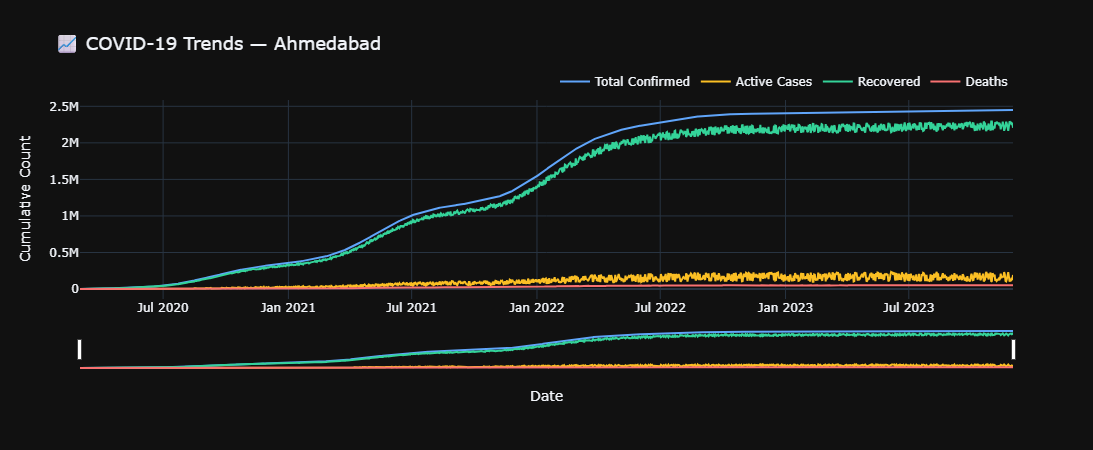

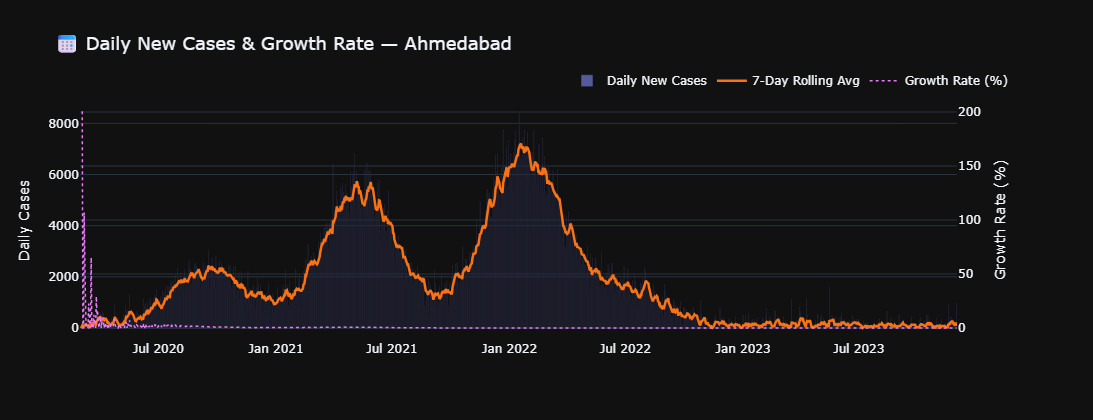

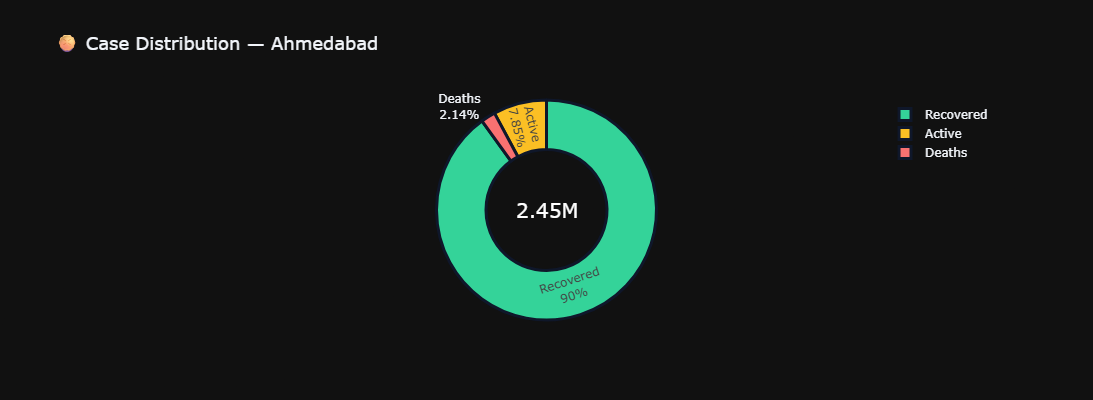

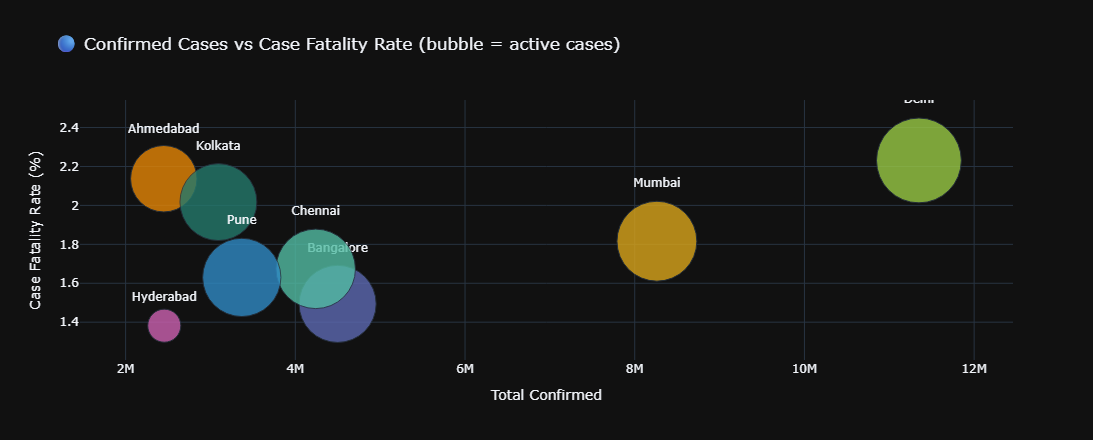

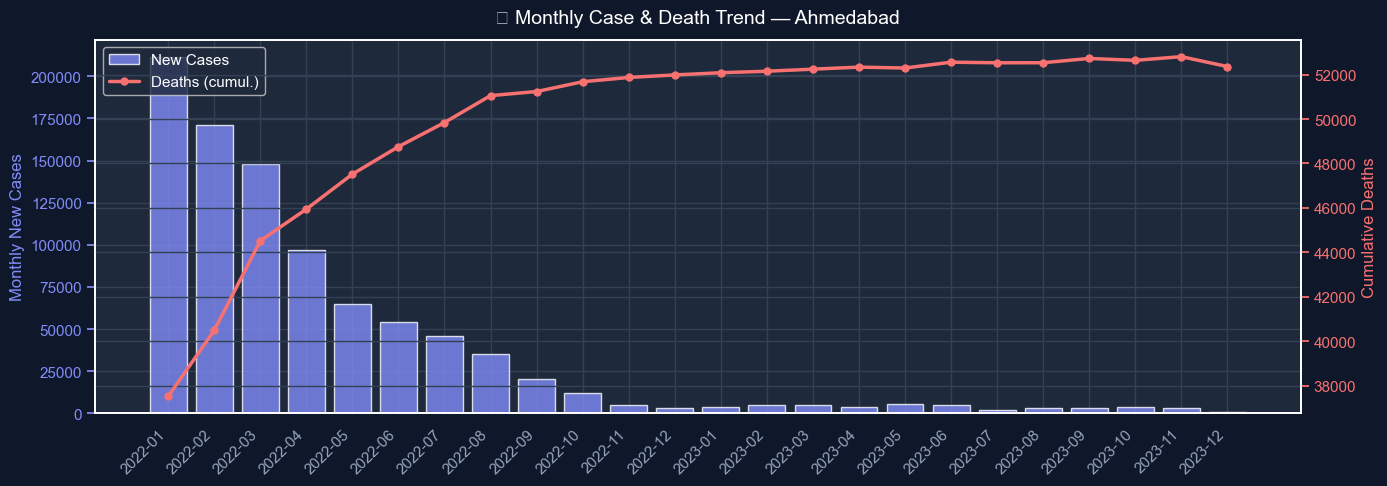

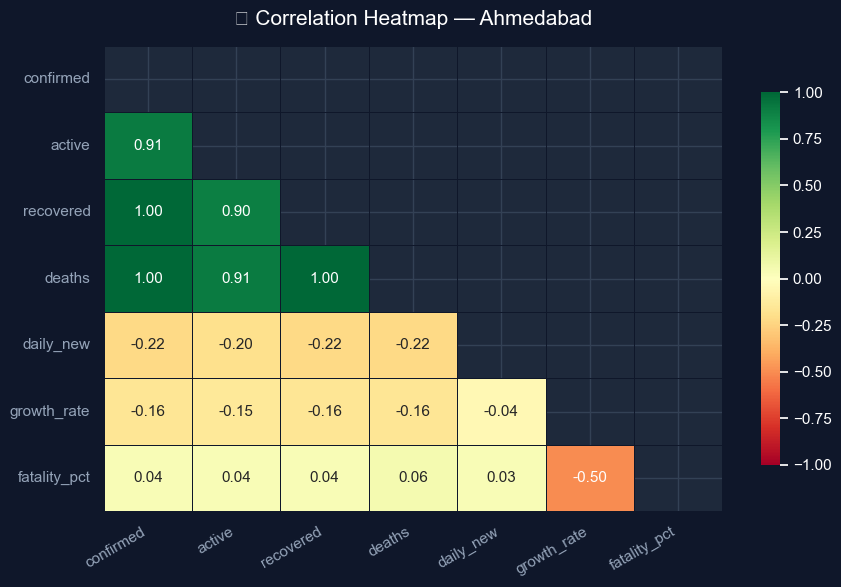

In [9]:
# ── Widget definitions ───────────────────────────────────────────────────────
style  = {'description_width': '100px'}
layout = widgets.Layout(width='320px')

w_city = widgets.Dropdown(
    options=CITIES, value=CITIES[0],
    description='🏙️ City:', style=style, layout=layout
)

all_dates  = pd.date_range(DATE_MIN, DATE_MAX, freq='MS')  # monthly
date_opts  = [(d.strftime('%b %Y'), d) for d in all_dates]

w_start = widgets.SelectionSlider(
    options=date_opts, value=date_opts[0][1],
    description='📅 Start:', style=style,
    layout=widgets.Layout(width='560px'),
    continuous_update=False
)
w_end = widgets.SelectionSlider(
    options=date_opts, value=date_opts[-1][1],
    description='📅 End:', style=style,
    layout=widgets.Layout(width='560px'),
    continuous_update=False
)

w_metric = widgets.ToggleButtons(
    options=['confirmed', 'active', 'recovered', 'deaths'],
    description='📊 Metric:', style=style,
    button_style='info',
    tooltips=['Total confirmed', 'Active cases', 'Recovered', 'Deaths']
)

btn_update = widgets.Button(
    description='🔄 Update Dashboard',
    button_style='success',
    layout=widgets.Layout(width='200px', height='38px')
)

out_single = widgets.Output()


# ── Dashboard render function ────────────────────────────────────────────────
def render_single_dashboard(_=None):
    """Render all single-city visualizations inside out_single."""
    city  = w_city.value
    start = pd.Timestamp(w_start.value)
    end   = pd.Timestamp(w_end.value)

    if start >= end:
        with out_single:
            clear_output()
            display(HTML('<p style="color:#f87171">⚠️ Start date must be before end date.</p>'))
        return

    sub = filter_data(DF, city, start, end)
    if sub.empty:
        with out_single:
            clear_output()
            display(HTML('<p style="color:#f87171">⚠️ No data for the selected range.</p>'))
        return

    kpis = latest_kpis(sub)

    with out_single:
        clear_output(wait=True)

        display(HTML(f'<div class="dash-section">📍 City: {city} &nbsp;|&nbsp; '
                     f'{start.strftime("%d %b %Y")} → {end.strftime("%d %b %Y")}</div>'))

        # KPI cards
        render_kpi_cards(kpis)

        # Line chart
        display(HTML('<div class="dash-section">📈 Case Trends Over Time</div>'))
        plot_line_chart(sub, city).show()

        # Daily + growth
        display(HTML('<div class="dash-section">📅 Daily New Cases & Growth Rate</div>'))
        plot_daily_cases(sub, city).show()

        # Side-by-side: pie + scatter
        display(HTML('<div class="dash-section">🥧 Distribution &nbsp;&nbsp;|&nbsp;&nbsp; 🔵 Scatter Analysis</div>'))
        plot_pie(sub, city).show()
        plot_scatter(DF, end).show()

        # Matplotlib charts
        display(HTML('<div class="dash-section">📆 Monthly Trend (Matplotlib)</div>'))
        plot_monthly_bar(sub, city)

        # Seaborn heatmap
        display(HTML('<div class="dash-section">🔥 Correlation Heatmap (Seaborn)</div>'))
        plot_corr_heatmap(sub, city)


# Wire up events
btn_update.on_click(render_single_dashboard)
w_city.observe(render_single_dashboard, names='value')

# Layout
controls = widgets.VBox([
    widgets.HTML('<div class="dash-section">⚙️ Single-City Controls</div>'),
    widgets.HBox([w_city, w_metric]),
    w_start,
    w_end,
    btn_update,
], layout=widgets.Layout(padding='12px', border='1px solid #334155',
                          background_color='#1e293b', border_radius='10px'))

display(controls, out_single)
render_single_dashboard()   # initial render

---
## 🏙️ 7. Multi-City Comparison Dashboard

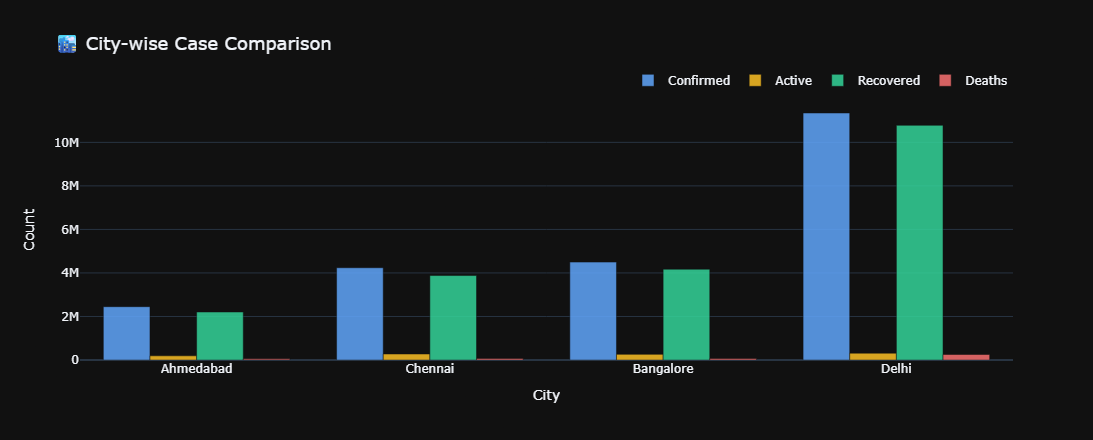

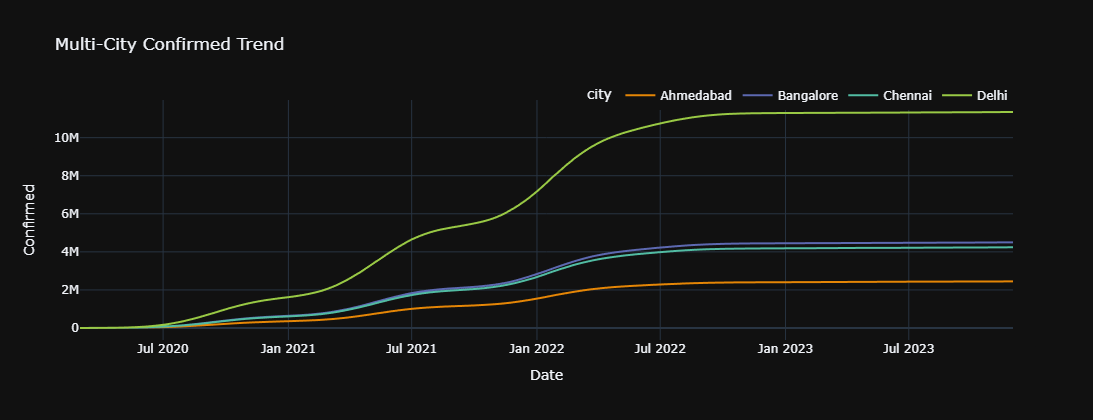

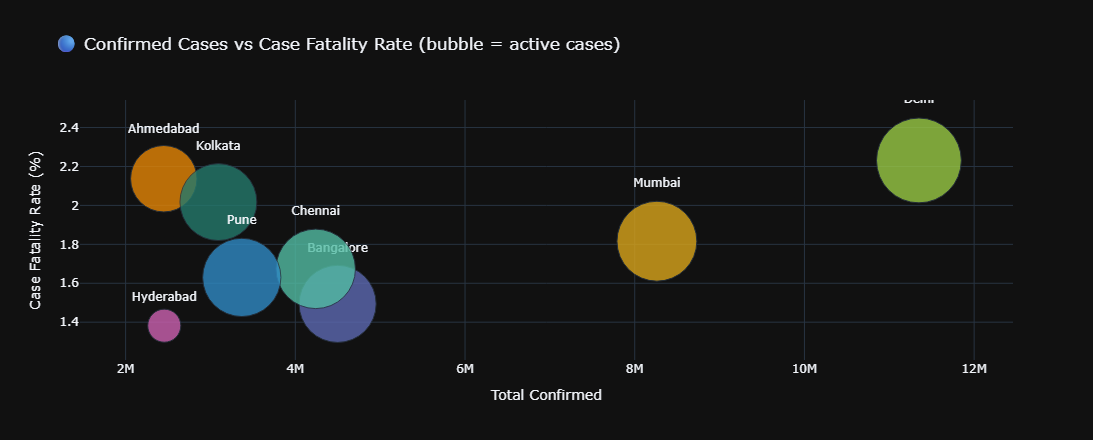

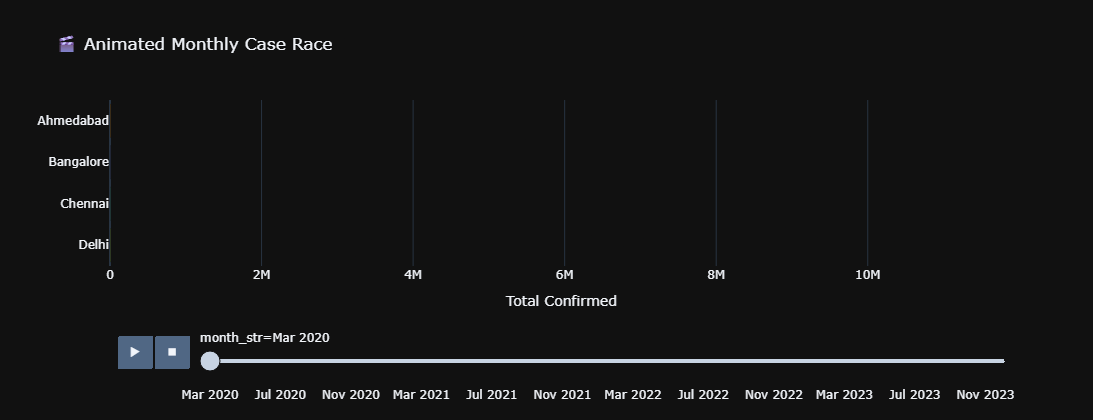

KeyError: 'city'

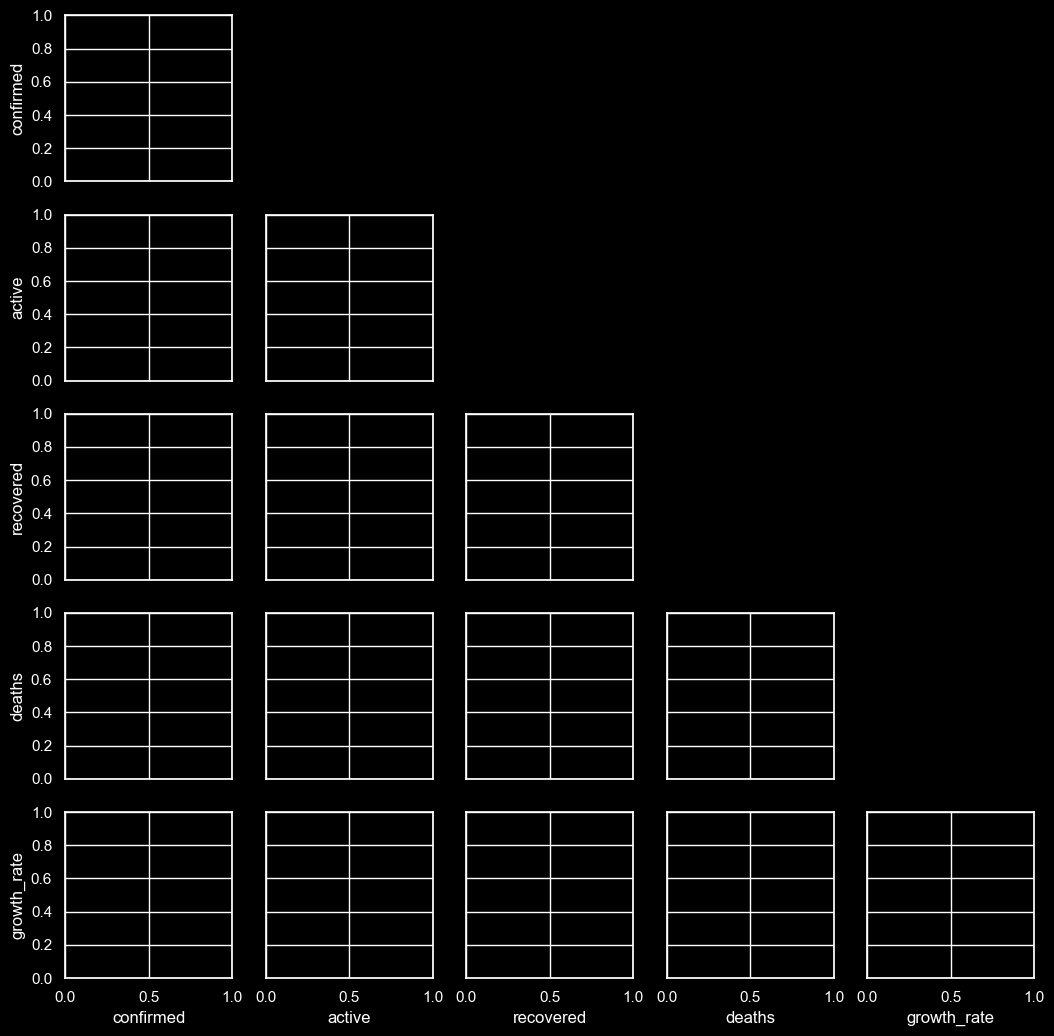

In [10]:
# ── Multi-city widget definitions ────────────────────────────────────────────
w_multi_cities = widgets.SelectMultiple(
    options=CITIES,
    value=CITIES[:4],
    description='🏙️ Cities:',
    rows=len(CITIES),
    style={'description_width': '80px'},
    layout=widgets.Layout(width='260px', height='180px')
)

w_multi_metric = widgets.Dropdown(
    options=['confirmed', 'active', 'recovered', 'deaths'],
    value='confirmed',
    description='📊 Metric:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='220px')
)

w_multi_end = widgets.SelectionSlider(
    options=date_opts, value=date_opts[-1][1],
    description='📅 As of:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='560px'),
    continuous_update=False
)

w_multi_start = widgets.SelectionSlider(
    options=date_opts, value=date_opts[0][1],
    description='📅 From:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='560px'),
    continuous_update=False
)

btn_multi = widgets.Button(
    description='🔄 Compare Cities',
    button_style='warning',
    layout=widgets.Layout(width='180px', height='38px')
)

out_multi = widgets.Output()


def render_multi_dashboard(_=None):
    """Render multi-city comparison visualizations."""
    cities = list(w_multi_cities.value)
    end    = pd.Timestamp(w_multi_end.value)
    start  = pd.Timestamp(w_multi_start.value)
    metric = w_multi_metric.value

    if len(cities) < 2:
        with out_multi:
            clear_output()
            display(HTML('<p style="color:#fbbf24">⚠️ Please select at least 2 cities.</p>'))
        return

    with out_multi:
        clear_output(wait=True)

        display(HTML(f'<div class="dash-section">🏙️ Comparing: {", ".join(cities)} '
                     f'| Metric: {metric.capitalize()}</div>'))

        # Grouped bar comparison
        display(HTML('<div class="dash-section">📊 Grouped Bar Chart</div>'))
        plot_bar_comparison(DF, cities, end, metric).show()

        # Multi-line overlay
        display(HTML('<div class="dash-section">📈 Multi-City Line Overlay</div>'))
        sub  = filter_multi(DF, cities, start, end)
        fig  = px.line(
            sub, x='date', y=metric, color='city',
            color_discrete_sequence=ACCENT_COLORS,
            template=PLOTLY_TEMPLATE,
            title=f'Multi-City {metric.capitalize()} Trend',
            labels={'date': 'Date', metric: metric.capitalize()},
        )
        fig.update_layout(height=420, hovermode='x unified',
                          legend=dict(orientation='h', y=1.08, xanchor='right', x=1))
        fig.show()

        # Scatter
        display(HTML('<div class="dash-section">🔵 CFR vs Confirmed Bubble Chart</div>'))
        plot_scatter(DF, end).show()

        # Animated race
        display(HTML('<div class="dash-section">🎬 Animated Bar Race (Monthly)</div>'))
        plot_race_animated(DF, cities, start, end).show()

        # Seaborn pairplot (sampled for speed)
        display(HTML('<div class="dash-section">🔗 Pairplot — Multi-City Sample (Seaborn)</div>'))
        sub_s = sub[['city', 'confirmed', 'active', 'recovered', 'deaths', 'growth_rate']].dropna()
        # Sample for performance
        sub_s = sub_s.groupby('city').apply(lambda g: g.sample(min(80, len(g)))).reset_index(drop=True)

        with plt.style.context('dark_background'):
            g = sns.pairplot(
                sub_s, hue='city', palette='tab10', corner=True, diag_kind='kde',
                plot_kws=dict(alpha=0.45, s=20),
                diag_kws=dict(fill=True, alpha=0.4)
            )
            g.fig.patch.set_facecolor('#0f172a')
            g.fig.suptitle('Seaborn Pairplot — Multi-City Metrics', y=1.02,
                           color='white', fontsize=14)
            plt.tight_layout()
            plt.show()


btn_multi.on_click(render_multi_dashboard)

multi_controls = widgets.VBox([
    widgets.HTML('<div class="dash-section">⚙️ Multi-City Controls</div>'),
    widgets.HBox([w_multi_cities, w_multi_metric]),
    w_multi_start,
    w_multi_end,
    btn_multi,
], layout=widgets.Layout(padding='12px', border='1px solid #334155', border_radius='10px'))

display(multi_controls, out_multi)
render_multi_dashboard()   # initial render

---
## 📉 8. Daily Growth Rate Analysis

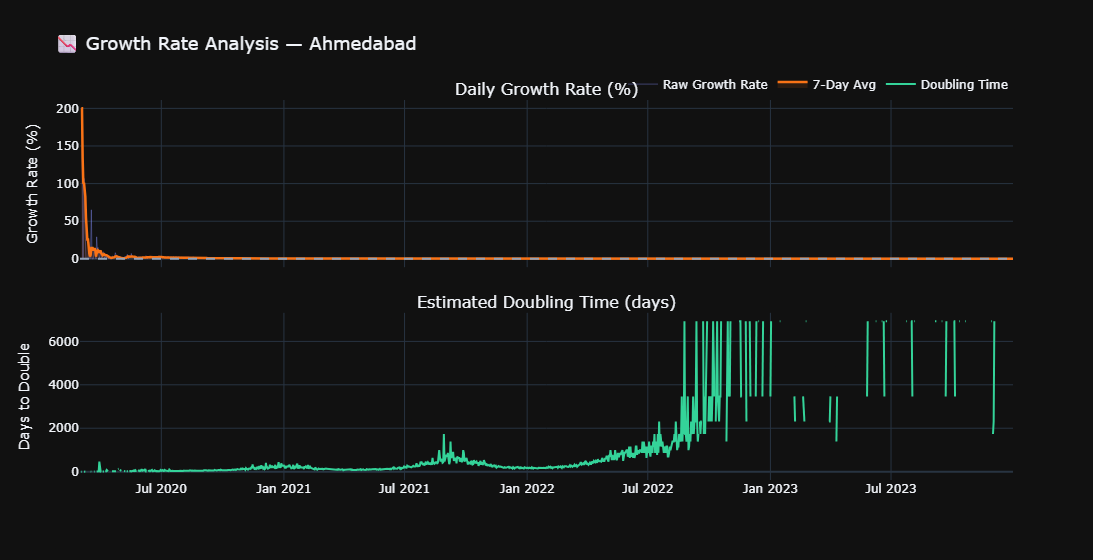

In [11]:
# ── Growth Rate Explorer ─────────────────────────────────────────────────────

w_gr_city  = widgets.Dropdown(
    options=CITIES, value=CITIES[0],
    description='🏙️ City:', style={'description_width': '80px'},
    layout=widgets.Layout(width='280px')
)
w_gr_window = widgets.IntSlider(
    value=7, min=3, max=30, step=1,
    description='📊 Window (days):',
    style={'description_width': '140px'},
    layout=widgets.Layout(width='440px'),
    continuous_update=False
)
out_gr = widgets.Output()


def render_growth(_=None):
    city   = w_gr_city.value
    window = w_gr_window.value
    sub    = filter_data(DF, city, DATE_MIN, DATE_MAX).copy()
    sub['smooth_growth'] = sub['growth_rate'].rolling(window, min_periods=1).mean()
    sub['doubling_days'] = (np.log(2) / np.log1p(sub['growth_rate'].clip(0) / 100)).replace([np.inf, -np.inf], np.nan)

    fig = make_subplots(rows=2, cols=1,
                        subplot_titles=('Daily Growth Rate (%)', 'Estimated Doubling Time (days)'),
                        shared_xaxes=True, vertical_spacing=0.12)

    fig.add_trace(go.Scatter(
        x=sub['date'], y=sub['growth_rate'],
        name='Raw Growth Rate', line=dict(color='#818cf8', width=1), opacity=0.4
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=sub['date'], y=sub['smooth_growth'],
        name=f'{window}-Day Avg', line=dict(color='#f97316', width=2.5),
        fill='tozeroy', fillcolor='rgba(249,115,22,0.12)'
    ), row=1, col=1)
    fig.add_hline(y=0, line_dash='dash', line_color='#94a3b8', row=1, col=1)

    fig.add_trace(go.Scatter(
        x=sub['date'], y=sub['doubling_days'],
        name='Doubling Time', line=dict(color='#34d399', width=2),
        hovertemplate='Doubling: %{y:.1f} days<extra></extra>'
    ), row=2, col=1)

    fig.update_layout(
        title=dict(text=f'📉 Growth Rate Analysis — {city}', font=dict(size=18)),
        template=PLOTLY_TEMPLATE, height=560, showlegend=True,
        legend=dict(orientation='h', y=1.08, xanchor='right', x=1)
    )
    fig.update_yaxes(title_text='Growth Rate (%)', row=1, col=1)
    fig.update_yaxes(title_text='Days to Double', row=2, col=1)

    with out_gr:
        clear_output(wait=True)
        display(HTML(f'<div class="dash-section">📉 Growth Rate & Doubling Time — {city} | '
                     f'{window}-day smoothing window</div>'))
        fig.show()


w_gr_city.observe(render_growth, names='value')
w_gr_window.observe(render_growth, names='value')

gr_controls = widgets.VBox([
    widgets.HTML('<div class="dash-section">⚙️ Growth Rate Controls</div>'),
    widgets.HBox([w_gr_city, w_gr_window]),
])
display(gr_controls, out_gr)
render_growth()

---
## 📋 9. Summary Statistics Table

In [12]:
# ── Styled summary table ─────────────────────────────────────────────────────
display(HTML('<div class="dash-section">📋 All-City Summary Statistics (latest snapshot)</div>'))

def build_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Latest-day stats for every city, formatted for display."""
    rows = []
    for city in CITIES:
        last = df[df['city'] == city].iloc[-1]
        rows.append({
            'City':          city,
            'Total Confirmed': f"{int(last['confirmed']):,}",
            'Active':          f"{int(last['active']):,}",
            'Recovered':       f"{int(last['recovered']):,}",
            'Deaths':          f"{int(last['deaths']):,}",
            'CFR (%)':         f"{last['fatality_pct']:.3f}",
            'Recovery (%)':    f"{last['recovery_pct']:.2f}",
            'Last Growth (%)': f"{last['growth_rate']:.2f}",
        })
    return pd.DataFrame(rows).set_index('City')

summary_df = build_summary(DF)

styled = (
    summary_df.style
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#1e3a5f'), ('color', '#e2e8f0'),
                  ('font-size', '12px'), ('padding', '8px 12px'),
                  ('border', '1px solid #334155')]
    }, {
        'selector': 'td',
        'props': [('background-color', '#1e293b'), ('color', '#cbd5e1'),
                  ('font-size', '13px'), ('padding', '7px 12px'),
                  ('border', '1px solid #334155')]
    }, {
        'selector': 'tr:hover td',
        'props': [('background-color', '#243556')]
    }])
    .highlight_max(subset=['CFR (%)'], color='#7f1d1d')
    .highlight_min(subset=['CFR (%)'], color='#14532d')
)

display(styled)

,Total Confirmed,Active,Recovered,Deaths,CFR (%),Recovery (%),Last Growth (%)
City,,,,,,,
Ahmedabad,"2,453,411","178,671","2,222,969","51,771",2.110,90.61,0.00
Bangalore,"4,501,082","242,551","4,190,481","68,050",1.512,93.10,0.00
Chennai,"4,243,327","113,213","4,056,069","74,045",1.745,95.59,0.02
Delhi,"11,352,621","470,312","10,635,597","246,712",2.173,93.68,0.01
Hyderabad,"2,457,911","53,255","2,369,924","34,732",1.413,96.42,0.00
Kolkata,"3,097,061","175,539","2,858,612","62,910",2.031,92.30,0.00
Mumbai,"8,267,384","206,726","7,912,947","147,711",1.787,95.71,0.00
Pune,"3,373,582","160,127","3,159,646","53,491",1.586,93.66,0.00


---
## 🌍 10. Global Seaborn Statistical Deep-Dive

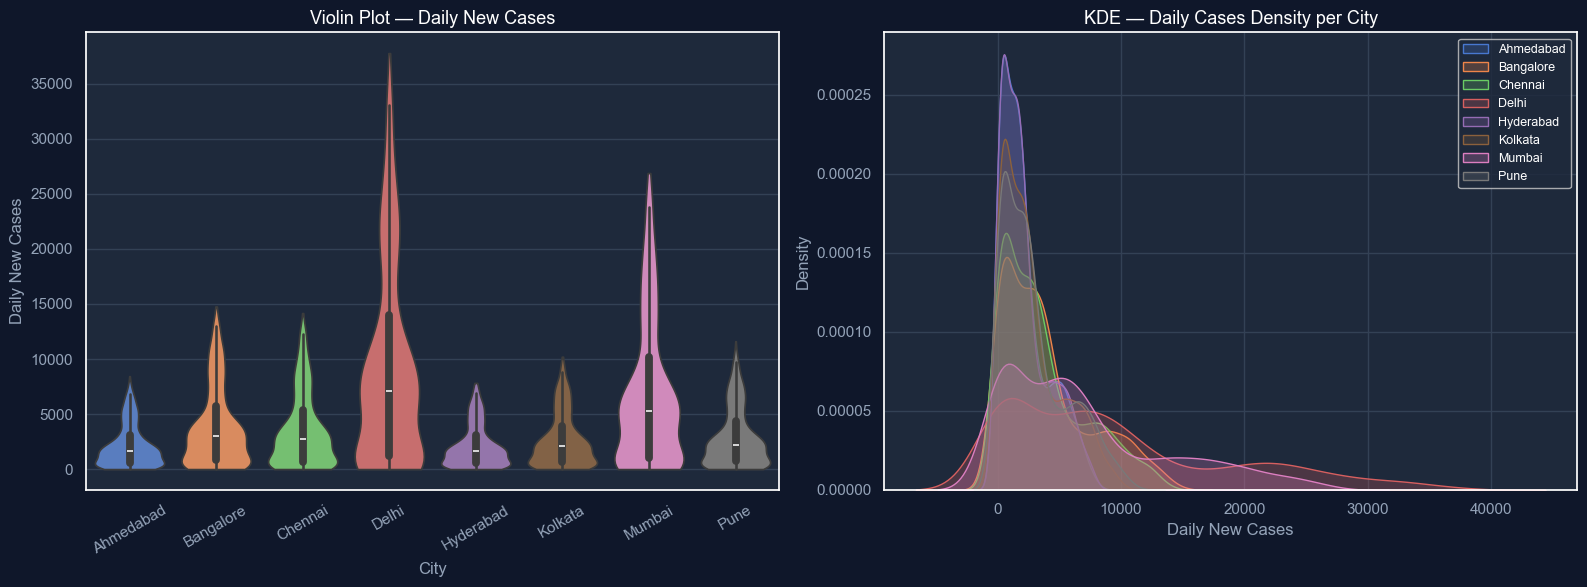

RuntimeError: clustermap requires scipy to be available

In [13]:
# ── Box-violin combo plot across all cities ──────────────────────────────────
display(HTML('<div class="dash-section">📦 Distribution of Daily New Cases — All Cities (Seaborn)</div>'))

sample = DF[DF['daily_new'] > 0].dropna(subset=['daily_new'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f172a')
for ax in axes:
    ax.set_facecolor('#1e293b')

# Violin plot
sns.violinplot(
    data=sample, x='city', y='daily_new',
    palette='muted', inner='box', ax=axes[0], cut=0
)
axes[0].set_title('Violin Plot — Daily New Cases', color='white', fontsize=13)
axes[0].set_xlabel('City', color='#94a3b8')
axes[0].set_ylabel('Daily New Cases', color='#94a3b8')
axes[0].tick_params(axis='x', rotation=30, colors='#94a3b8')
axes[0].tick_params(axis='y', colors='#94a3b8')

# KDE plot
for city in CITIES:
    city_data = sample[sample['city'] == city]['daily_new']
    sns.kdeplot(data=city_data, ax=axes[1], label=city, fill=True, alpha=0.25)

axes[1].set_title('KDE — Daily Cases Density per City', color='white', fontsize=13)
axes[1].set_xlabel('Daily New Cases', color='#94a3b8')
axes[1].set_ylabel('Density', color='#94a3b8')
axes[1].tick_params(colors='#94a3b8')
axes[1].legend(fontsize=9, facecolor='#1e293b', labelcolor='white')

plt.tight_layout()
plt.show()


# ── Clustermap of city correlations ─────────────────────────────────────────
display(HTML('<div class="dash-section">🧬 City-Metric Clustermap (Seaborn)</div>'))

pivot = (
    DF.groupby('city')[['confirmed', 'active', 'recovered', 'deaths',
                         'growth_rate', 'fatality_pct']]
      .mean()
      .round(2)
)

# Z-score normalize
pivot_norm = (pivot - pivot.mean()) / pivot.std()

with plt.style.context('dark_background'):
    g = sns.clustermap(
        pivot_norm, cmap='RdYlBu_r', annot=pivot.round(0), fmt='.0f',
        figsize=(11, 7), linewidths=0.5, linecolor='#0f172a',
        cbar_kws={'label': 'Z-score'},
        annot_kws={'size': 9, 'color': 'white'}
    )
    g.fig.patch.set_facecolor('#0f172a')
    g.ax_heatmap.patch.set_facecolor('#1e293b')
    g.fig.suptitle('City × Metric Clustermap (Z-score normalized)', y=1.02,
                   color='white', fontsize=14)
    plt.show()

---
## ✅ Dashboard Complete!

| Section | Tool | Purpose |
|---|---|---|
| KPI Cards | HTML/CSS | At-a-glance metrics |
| Line Chart | Plotly GO | Trend analysis with range slider |
| Daily Bar + Growth | Plotly GO | Daily cases & growth overlay |
| Pie / Donut | Plotly GO | Case distribution |
| Grouped Bar | Plotly Express | City comparison |
| Bubble Scatter | Plotly Express | CFR vs Confirmed |
| Animated Bar Race | Plotly Express | Monthly case race |
| Monthly Bar | Matplotlib | Long-term trend |
| Correlation Heatmap | Seaborn | Feature correlation |
| Pairplot | Seaborn | Multi-metric relationships |
| Violin + KDE | Seaborn | Distribution shape |
| Clustermap | Seaborn | City clustering |
| Growth Rate Calc | Pandas + Plotly | Doubling time analysis |
| Summary Table | Pandas Styler | Formatted city stats |